In [1]:
!pip install torch torchvision timm scikit-learn tqdm pillow scipy

In [22]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from scipy.stats import entropy

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import f1_score

torch.backends.cudnn.benchmark = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [23]:
IMAGE_ROOT = r"C:\Users\Debabrata\Downloads\wikiart\wikiart"
CSV_ROOT   = r"C:\Users\Debabrata\Downloads\wikiart_csv"

In [24]:
def load_split(csv_name, label):

    df = pd.read_csv(
        os.path.join(CSV_ROOT, csv_name),
        header=None,
        names=["image", label]
    )

    df["path"] = df["image"].apply(
        lambda x: os.path.join(IMAGE_ROOT, str(x).replace("/", "\\"))
    )

    df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)
    return df


style_train = load_split("style_train.csv","style_id")
style_val   = load_split("style_val.csv","style_id")

artist_train = load_split("artist_train.csv","artist_id")
artist_val   = load_split("artist_val.csv","artist_id")

genre_train = load_split("genre_train.csv","genre_id")
genre_val   = load_split("genre_val.csv","genre_id")

In [25]:
def prepare(df, missing_cols):
    for c in missing_cols:
        df[c] = np.nan
    return df

style_train = prepare(style_train, ["artist_id","genre_id"])
style_val   = prepare(style_val,   ["artist_id","genre_id"])

artist_train = prepare(artist_train, ["style_id","genre_id"])
artist_val   = prepare(artist_val,   ["style_id","genre_id"])

genre_train = prepare(genre_train, ["style_id","artist_id"])
genre_val   = prepare(genre_val,   ["style_id","artist_id"])

train_meta = pd.concat(
    [style_train, artist_train, genre_train],
    ignore_index=True
)

val_meta = pd.concat(
    [style_val, artist_val, genre_val],
    ignore_index=True
)

# remove rows without any label
def has_label(r):
    return (
        not pd.isna(r.style_id) or
        not pd.isna(r.artist_id) or
        not pd.isna(r.genre_id)
    )

train_meta = train_meta[train_meta.apply(has_label,axis=1)]
val_meta   = val_meta[val_meta.apply(has_label,axis=1)]

In [26]:
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


class WikiArtDataset(Dataset):

    def __init__(self, df, tfms):
        self.df=df.reset_index(drop=True)
        self.tfms=tfms

    def __len__(self): return len(self.df)

    def __getitem__(self,i):

        r=self.df.iloc[i]
        img=Image.open(r.path).convert("RGB")
        img=self.tfms(img)

        def safe(x): return -1 if pd.isna(x) else int(x)

        return img, safe(r.style_id), safe(r.artist_id), safe(r.genre_id)

In [27]:
# Check initial load counts
print(f"Style Train rows: {len(style_train)}")
print(f"Artist Train rows: {len(artist_train)}")
print(f"Genre Train rows: {len(genre_train)}")

# Check path validity
sample_path = style_train.iloc[0]['path'] if len(style_train) > 0 else "No data"
print(f"Sample Image Path: {sample_path}")
print(f"Does it exist? {os.path.exists(sample_path)}")

# Check meta counts before and after the 'has_label' filter
temp_meta = pd.concat([style_train, artist_train, genre_train], ignore_index=True)
print(f"Combined Meta (Before Filter): {len(temp_meta)}")

final_meta = temp_meta[temp_meta.apply(has_label, axis=1)]
print(f"Combined Meta (After Filter): {len(final_meta)}")

Style Train rows: 57023
Artist Train rows: 13344
Genre Train rows: 45501
Sample Image Path: C:\Users\Debabrata\Downloads\wikiart\wikiart\Impressionism\edgar-degas_landscape-on-the-orne.jpg
Does it exist? True
Combined Meta (Before Filter): 115868
Combined Meta (After Filter): 115868


In [28]:
train_loader = DataLoader(
    WikiArtDataset(train_meta,train_tfms),
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    WikiArtDataset(val_meta,val_tfms),
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [30]:
class CRNN(nn.Module):

    def __init__(self,ns,na,ng):
        super().__init__()

        backbone=models.resnet50(weights="DEFAULT")
        self.cnn=nn.Sequential(*list(backbone.children())[:-2])

        self.rnn=nn.LSTM(
            2048,512,
            batch_first=True,
            bidirectional=True
        )

        self.pool=nn.AdaptiveAvgPool1d(1)

        self.style=nn.Linear(1024,ns)
        self.artist=nn.Linear(1024,na)
        self.genre=nn.Linear(1024,ng)

    def forward(self,x):

        f=self.cnn(x)
        B,C,H,W=f.shape
        seq=f.permute(0,2,3,1).reshape(B,H*W,C)

        rnn,_=self.rnn(seq)
        feat=self.pool(rnn.transpose(1,2)).squeeze(-1)

        return self.style(feat),self.artist(feat),self.genre(feat)

In [31]:
model = CRNN(
    style_train.style_id.nunique(),
    artist_train.artist_id.nunique(),
    genre_train.genre_id.nunique()
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

In [32]:
def masked_loss(pred,target):

    mask=target!=-1
    if mask.sum()==0:
        return None
    return criterion(pred[mask],target[mask])

In [33]:
def train_epoch(loader):

    model.train()
    total,steps=0,0

    for imgs,s,a,g in tqdm(loader):

        imgs=imgs.to(DEVICE)
        s,a,g=s.to(DEVICE),a.to(DEVICE),g.to(DEVICE)

        optimizer.zero_grad()

        ps,pa,pg=model(imgs)

        losses=[l for l in [
            masked_loss(ps,s),
            masked_loss(pa,a),
            masked_loss(pg,g)
        ] if l is not None]

        if not losses: continue

        loss=torch.stack(losses).mean()
        loss.backward()
        optimizer.step()

        total+=loss.item()
        steps+=1

    return total/max(steps,1)

In [34]:
def evaluate(loader):

    model.eval()

    style_preds, style_targets = [], []
    artist_preds, artist_targets = [], []
    genre_preds, genre_targets = [], []

    top5_correct = 0
    top5_total = 0

    entropies = []

    with torch.no_grad():

        for imgs, s, a, g in loader:

            imgs = imgs.to(DEVICE)
            ps, pa, pg = model(imgs)

            # ================= STYLE =================
            mask = s != -1
            if mask.sum() > 0:

                probs = torch.softmax(ps[mask], dim=1)

                preds = probs.argmax(dim=1).cpu().numpy()
                style_preds.extend(preds)
                style_targets.extend(s[mask].numpy())

                # ----- TOP-5 ACCURACY -----
                top5 = torch.topk(probs, k=5, dim=1).indices
                targets = s[mask].unsqueeze(1)

                top5_correct += (
                    top5.cpu() == targets
                ).any(dim=1).sum().item()

                top5_total += len(targets)

                # entropy
                entropies.extend(
                    (-probs.cpu().numpy()
                     * np.log(probs.cpu().numpy()+1e-9)
                    ).sum(axis=1)
                )

            # ================= ARTIST =================
            mask = a != -1
            if mask.sum() > 0:
                preds = pa[mask].argmax(1).cpu().numpy()
                artist_preds.extend(preds)
                artist_targets.extend(a[mask].numpy())

            # ================= GENRE =================
            mask = g != -1
            if mask.sum() > 0:
                preds = pg[mask].argmax(1).cpu().numpy()
                genre_preds.extend(preds)
                genre_targets.extend(g[mask].numpy())

    # -------- METRICS --------
    style_f1  = f1_score(style_targets, style_preds, average="macro")
    artist_f1 = f1_score(artist_targets, artist_preds, average="macro")
    genre_f1  = f1_score(genre_targets, genre_preds, average="macro")

    top5_acc = top5_correct / max(top5_total, 1)
    mean_entropy = np.mean(entropies)

    print("\nValidation Metrics")
    print("------------------")
    print("Style Macro-F1 :", round(style_f1,4))
    print("Artist Macro-F1:", round(artist_f1,4))
    print("Genre Macro-F1 :", round(genre_f1,4))
    print("Top-5 Accuracy :", round(top5_acc,4))
    print("Mean Entropy   :", round(mean_entropy,4))

    return mean_entropy

In [13]:
EPOCHS=50
PATIENCE=10

best_score=float("inf")
patience_counter=0
SAVE_PATH="best_crnn.pt"

for epoch in range(EPOCHS):

    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    loss=train_epoch(train_loader)
    print("Train Loss:",round(loss,4))

    val_entropy=evaluate(val_loader)

    if val_entropy<best_score:
        print("✅ Saving best model")
        best_score=val_entropy
        patience_counter=0

        torch.save(model.state_dict(),SAVE_PATH)
    else:
        patience_counter+=1
        print(f"No improvement {patience_counter}/{PATIENCE}")

    if patience_counter>=PATIENCE:
        print("⛔ Early stopping")
        break


===== Epoch 1/50 =====


  6%|▌         | 111/1811 [02:41<39:27,  1.39s/it]c:\Users\Debabrata\anaconda3\envs\BRIGHT\Lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (99962094 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
 27%|██▋       | 497/1811 [11:12<28:12,  1.29s/it]c:\Users\Debabrata\anaconda3\envs\BRIGHT\Lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (107327830 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
100%|██████████| 1811/1811 [36:36<00:00,  1.21s/it]


Train Loss: 1.1937

Validation Metrics
------------------
Style Macro-F1 : 0.4309
Artist Macro-F1: 0.7476
Genre Macro-F1 : 0.6882
Top-5 Accuracy : 0.9108
Mean Entropy   : 1.3745
✅ Saving best model

===== Epoch 2/50 =====


 25%|██▍       | 447/1811 [07:27<22:11,  1.02it/s]c:\Users\Debabrata\anaconda3\envs\BRIGHT\Lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (107327830 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
 41%|████▏     | 749/1811 [12:32<18:52,  1.07s/it]c:\Users\Debabrata\anaconda3\envs\BRIGHT\Lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (99962094 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
100%|██████████| 1811/1811 [30:19<00:00,  1.00s/it]


Train Loss: 0.8448

Validation Metrics
------------------
Style Macro-F1 : 0.5166
Artist Macro-F1: 0.8084
Genre Macro-F1 : 0.7228
Top-5 Accuracy : 0.9298
Mean Entropy   : 1.2397
✅ Saving best model

===== Epoch 3/50 =====


...

Train Loss: 0.0529

Validation Metrics
------------------
Style Macro-F1 : 0.6042
Artist Macro-F1: 0.8466
Genre Macro-F1 : 0.7437
Top-5 Accuracy : 0.9331
Mean Entropy   : 0.4336
No improvement 6/10

===== Epoch 49/50 =====


  2%|▏         | 33/1811 [00:33<30:41,  1.04s/it]c:\Users\Debabrata\anaconda3\envs\BRIGHT\Lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (99962094 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
 10%|█         | 186/1811 [03:08<26:49,  1.01it/s]c:\Users\Debabrata\anaconda3\envs\BRIGHT\Lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (107327830 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
100%|██████████| 1811/1811 [30:09<00:00,  1.00it/s]


Train Loss: 0.053

Validation Metrics
------------------
Style Macro-F1 : 0.5972
Artist Macro-F1: 0.8498
Genre Macro-F1 : 0.7499
Top-5 Accuracy : 0.9319
Mean Entropy   : 0.4226
No improvement 7/10

===== Epoch 50/50 =====


  6%|▋         | 117/1811 [01:59<29:59,  1.06s/it]c:\Users\Debabrata\anaconda3\envs\BRIGHT\Lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (107327830 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
 44%|████▎     | 788/1811 [13:09<17:08,  1.01s/it]c:\Users\Debabrata\anaconda3\envs\BRIGHT\Lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (99962094 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
100%|██████████| 1811/1811 [30:13<00:00,  1.00s/it]


Train Loss: 0.0565

Validation Metrics
------------------
Style Macro-F1 : 0.5911
Artist Macro-F1: 0.8372
Genre Macro-F1 : 0.74
Top-5 Accuracy : 0.9276
Mean Entropy   : 0.441
No improvement 8/10


In [14]:
model.load_state_dict(torch.load(SAVE_PATH))
print("Best model loaded.")

evaluate(val_loader)

Best model loaded.

Validation Metrics
------------------
Style Macro-F1 : 0.6028
Artist Macro-F1: 0.8522
Genre Macro-F1 : 0.7473
Top-5 Accuracy : 0.9365
Mean Entropy   : 0.4185


0.41849715

In [35]:
# Assuming 'probs' is your model output [N, num_classes]
import torch

# Calculate Entropy: -sum(p * log(p))
entropy = -torch.sum(probs * torch.log(probs + 1e-10), dim=1)

# Find the indices of the highest entropy (most 'confused' images)
outlier_indices = torch.topk(entropy, 5).indices

print("Task 1 Outliers (Highest Uncertainty):")
for idx in outlier_indices:
    print(f"Image Index: {idx.item()} | Entropy Score: {entropy[idx].item():.4f}")

NameError: name 'probs' is not defined

In [36]:
# 1. Re-initialize the model architecture with the correct class counts
model = CRNN(
    style_train.style_id.nunique(),
    artist_train.artist_id.nunique(),
    genre_train.genre_id.nunique()
).to(DEVICE)

# 2. Load the weights from your specific path
CHECKPOINT_PATH = r"C:\Users\Debabrata\Desktop\Bright\BRIGHT\ARTWICGAN\best_crnn.pt"
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()  # Set to evaluation mode

print("Checkpoint successfully loaded for Task 1 evaluation!")

Checkpoint successfully loaded for Task 1 evaluation!


In [37]:
# Task 1: Identifying Outliers via Prediction Uncertainty
model.eval()
all_probs = []
all_paths = []

with torch.no_grad():
    for imgs, s, a, g in val_loader:
        imgs = imgs.to(DEVICE)
        ps, pa, pg = model(imgs)
        # Using Style probabilities as a proxy for 'Style/Genre' fit
        probs = torch.softmax(ps, dim=1)
        all_probs.append(probs.cpu())

# Stack all probabilities [N, num_classes]
probs_tensor = torch.cat(all_probs)

# Calculate Entropy: Higher entropy = Higher uncertainty (Potential Outliers)
entropy_vals = -torch.sum(probs_tensor * torch.log(probs_tensor + 1e-10), dim=1)

# Find top 5 outliers
outlier_scores, outlier_indices = torch.topk(entropy_vals, 5)

print("Task 1 Outliers (Highest Prediction Uncertainty):")
for i in range(5):
    idx = outlier_indices[i].item()
    print(f"Image Index: {idx} | Entropy: {outlier_scores[i]:.4f}")

Task 1 Outliers (Highest Prediction Uncertainty):
Image Index: 36618 | Entropy: 2.2714
Image Index: 4576 | Entropy: 2.2714
Image Index: 48853 | Entropy: 2.2128
Image Index: 23466 | Entropy: 2.2128
Image Index: 43774 | Entropy: 2.1824


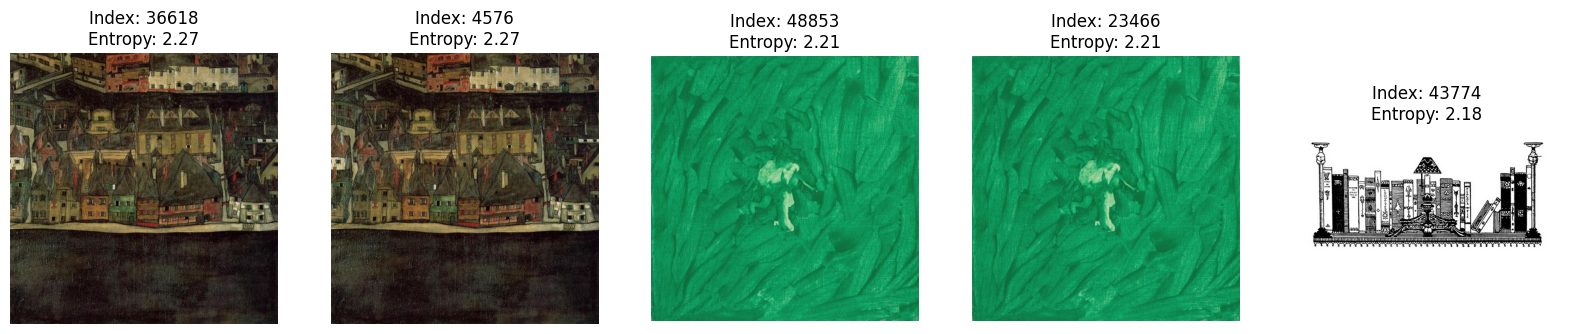

In [38]:
# Assuming 'val_meta' is your validation dataframe
outlier_indices = [36618, 4576, 48853, 23466, 43774]
outlier_data = val_meta.iloc[outlier_indices]

import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(20, 5))
for i, (idx, row) in enumerate(outlier_data.iterrows()):
    plt.subplot(1, 5, i+1)
    img = Image.open(row['path'])
    plt.imshow(img)
    plt.title(f"Index: {idx}\nEntropy: {entropy_vals[idx]:.2f}")
    plt.axis('off')
plt.show()